# Netflix Data Analysis

## Objective
Analyze Netflix dataset to discover trends, content distribution, ratings, genres, and country-wise insights.

In [43]:
# Import necessary libraries for data analysis and visualization

import pandas as pd              # For data manipulation
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For advanced visualization

In [44]:
# Load Netflix dataset from local folder

df = pd.read_csv('../data/netflix_titles.csv')

# Display first 5 rows to understand data structure
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [45]:
# Display last 5 rows to understand data structure
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [46]:
# Check shape of dataset (rows, columns)
df.shape

(8807, 12)

In [47]:
# Check column names
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [48]:
# Get summary of dataset (data types, null values)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [49]:
# Check how many missing values exist in each column
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [50]:
#shows basic Statistics
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [51]:
# Check how many duplicate values exist in each column
df.duplicated().sum()

np.int64(0)

# Data Cleaning and Feature Engineering

In [52]:
# Fill missing categorical values with 'Unknown' or 'Not Rated'

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

In [53]:
# Remove leading and trailing spaces from 'date_added' column to ensure consistent formatting before conversion to datetime
df['date_added'] = df['date_added'].str.strip()


In [54]:
#checking null value after handling missing values
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [55]:
# Convert 'date_added' from string format to datetime format
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [56]:
# Filter and display rows where 'date_added' is missing to identify problematic entries in the dataset
# Showing only 'title' and 'date_added' columns for easier inspection of affected records

df[df['date_added'].isnull()][['title', 'date_added']]

,title,date_added
6066,A Young Doctor's Notebook and Other Stories,NaT
6174,Anthony Bourdain: Parts Unknown,NaT
6795,Frasier,NaT
6806,Friends,NaT
6901,Gunslinger Girl,NaT
7196,Kikoriki,NaT
7254,La Familia P. Luche,NaT
7406,Maron,NaT
7847,Red vs. Blue,NaT
8182,The Adventures of Figaro Pho,NaT


In [57]:
# Remove rows where 'date_added' is missing because these records cannot be used for time-based analysis
df = df.dropna(subset=['date_added'])

In [58]:
# Extract year from 'date_added' column to analyze yearly content trends on Netflix
df['year_added'] = df['date_added'].dt.year

In [59]:
#checking year_added values after adding new column
df['year_added']

0       2021
1       2021
2       2021
3       2021
4       2021
        ... 
8802    2019
8803    2019
8804    2019
8805    2020
8806    2019
Name: year_added, Length: 8797, dtype: int32

In [60]:
# Display all column names to verify dataset structure after transformations
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='str')

In [61]:
# Check remaining missing values in each column after data cleaning
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
dtype: int64

# Visualization

### Movies vs TV Shows Analysis

In [62]:
# Count number of Movies vs TV Shows
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

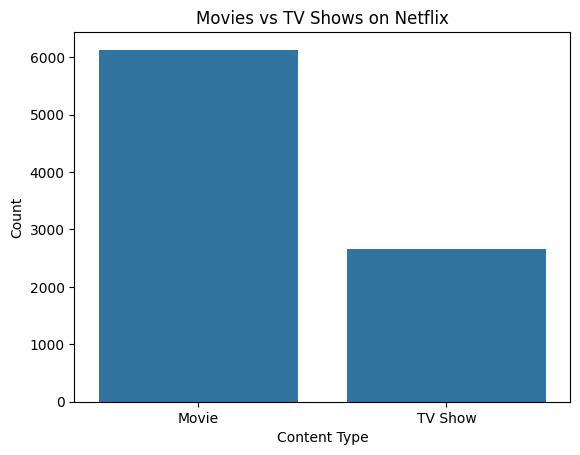

In [63]:
# Visualize Movies vs TV Shows distribution

sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

### Insight:
- Netflix has significantly more Movies than TV Shows.  
- This shows that the platform focuses more on movie content compared to series.  
- It may also indicate higher demand or easier production of movies.

### Top 10 Countries

In [64]:
# Find top 10 countries producing Netflix content
top_countries = df['country'].value_counts().head(10)
top_countries

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

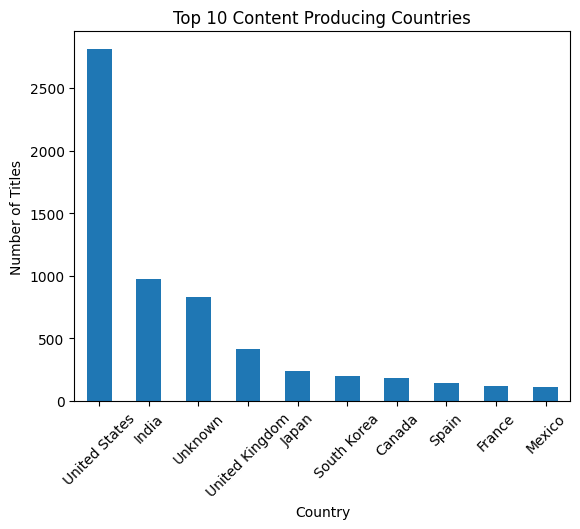

In [65]:
# Visualize top 10 countries

top_countries.plot(kind='bar')

plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.show()

### Insight:
- The United States dominates Netflix content production by a large margin.  
- Other countries like India and the UK also contribute significantly.  
- This shows Netflix's strong US-based content strategy.

### Content Added Over Years

In [66]:
# Analyze how Netflix content has grown over time

df['year_added'].value_counts().sort_index()

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

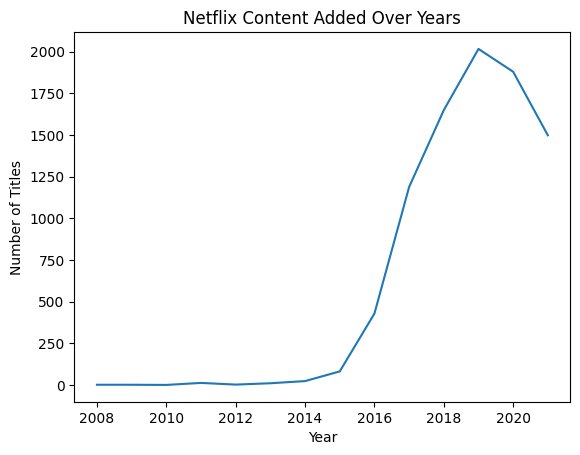

In [67]:
# Visualize content growth over years

df['year_added'].value_counts().sort_index().plot()

plt.title('Netflix Content Added Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

### Insight:
- Netflix content has grown rapidly after 2015, with a peak between 2018–2020.  
- This reflects Netflix’s global expansion phase during those years.

### Ratings Distribution

In [68]:
# Check distribution of content ratings

df['rating'].value_counts().head(10)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64

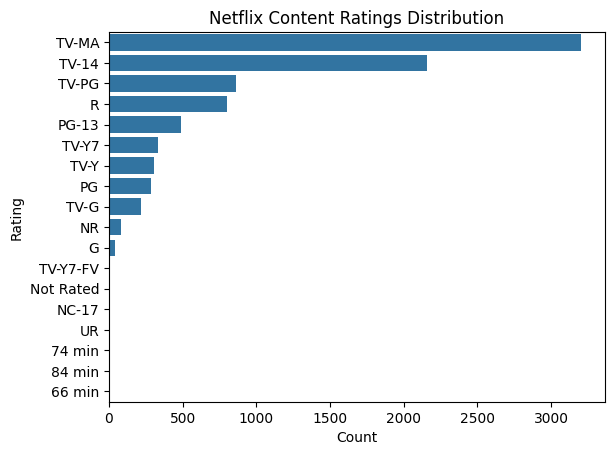

In [69]:
# Visualize ratings distribution

sns.countplot(y='rating', data=df,
              order=df['rating'].value_counts().index)

plt.title('Netflix Content Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')

plt.show()

### Insight:
- Netflix content is heavily dominated by the TV-MA rating, which indicates a large portion of content is intended for mature audiences.  
- This suggests Netflix focuses more on adult-oriented content compared to family or kids content.  
- Other ratings like TV-14 and TV-PG also appear, but with much lower frequency.

### Top Genres

In [70]:
# Split genres and analyze most common ones

genres = df['listed_in'].str.split(', ', expand=True).stack()
genres.value_counts().head(10)

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

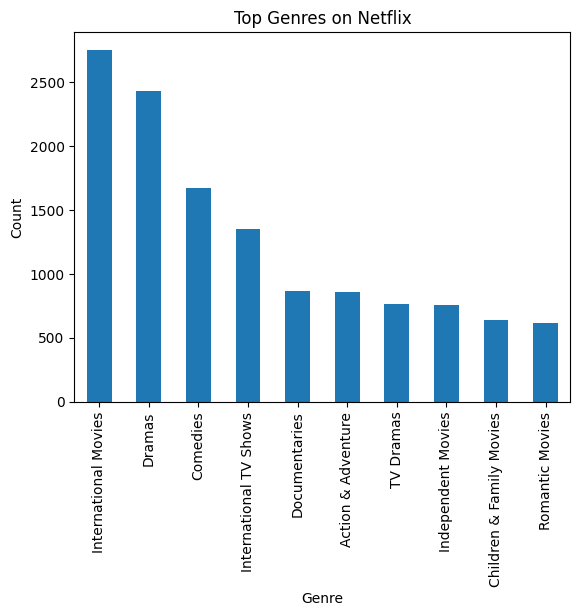

In [71]:
# Visualize top genres

genres.value_counts().head(10).plot(kind='bar')

plt.title('Top Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.show()

### Insight:
- Dramas and Comedies are the most common genres on Netflix, showing a strong preference for storytelling-based content.  
- Documentaries and action-related genres also appear frequently, but in smaller proportions.  
- This indicates Netflix prioritizes engaging, narrative-driven content to attract users.

# Statistical Analysis

## Distribution of Release Years

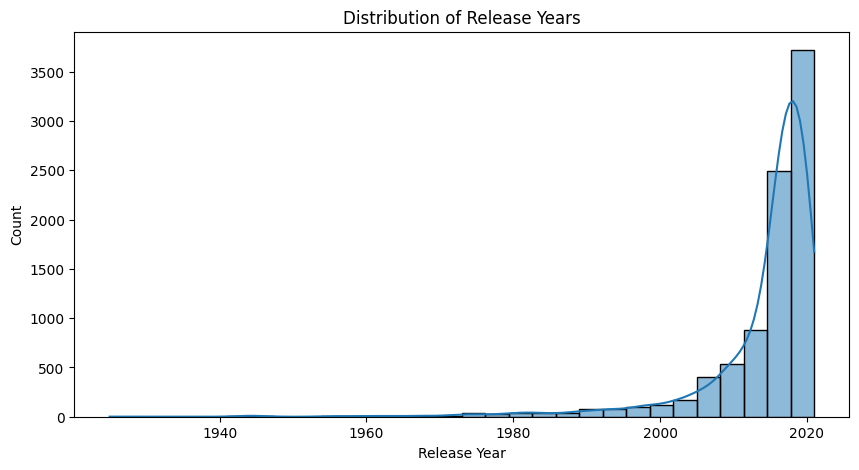

In [72]:
# Analyze distribution of content release years

plt.figure(figsize=(10,5))

sns.histplot(df['release_year'], bins=30, kde=True)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

### Insight:
Most Netflix content was released after the year 2000, with a sharp increase after 2010.  
This indicates Netflix mainly focuses on modern and recent content.

## Mean Release Year

In [73]:
# Calculate average release year of Netflix content

mean_release_year = df['release_year'].mean()

print("Mean Release Year:", mean_release_year)

Mean Release Year: 2014.1834716380583


### Insight:
The average release year suggests that Netflix content is generally modern rather than old classic content.

## Median Release Year

In [74]:
# Calculate median release year

median_release_year = df['release_year'].median()

print("Median Release Year:", median_release_year)

Median Release Year: 2017.0


### Insight:
The median release year helps identify the central tendency of the dataset and is less affected by extreme old or new values.

## Movie Duration Analysis

In [75]:
# Filter only Movies

movies_df = df[df['type'] == 'Movie'].copy()

# Extract numeric duration values from 'duration' column

movies_df['duration_int'] = movies_df['duration'].str.extract(r'(\d+)')

# Convert extracted values into integer type

movies_df['duration_int'] = movies_df['duration_int'].astype(float)

## Distribution of Movie Duration

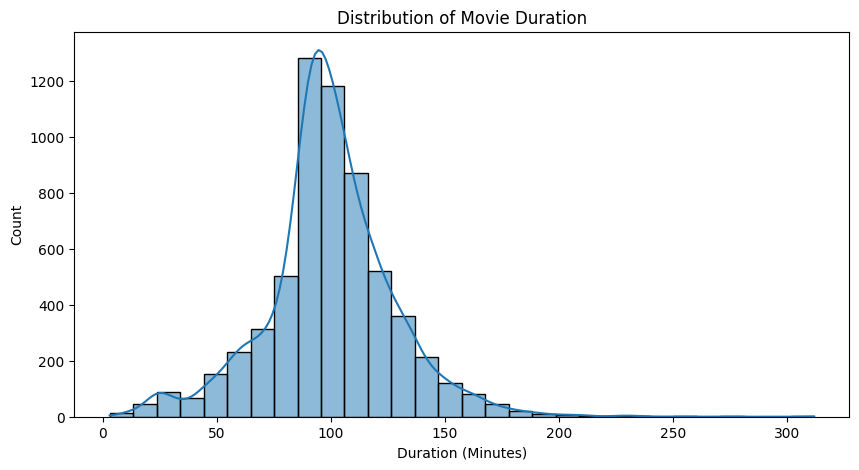

In [76]:
# Visualize distribution of movie durations

plt.figure(figsize=(10,5))

sns.histplot(movies_df['duration_int'], bins=30, kde=True)

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Count')

plt.show()

### Insight:
Most Netflix movies are between 80–120 minutes long, which reflects standard movie industry duration trends.

## Mean Movie Duration

In [77]:
# Calculate average movie duration

mean_duration = movies_df['duration_int'].mean()

print("Average Movie Duration:", mean_duration)

Average Movie Duration: 99.57718668407311


## Median Movie Duration

In [78]:
# Calculate median movie duration

median_duration = movies_df['duration_int'].median()

print("Median Movie Duration:", median_duration)

Median Movie Duration: 98.0


### Insight:
The mean and median movie durations are very close, suggesting movie durations are relatively balanced without extreme outliers.

## Correlation Analysis

In [79]:
# Select numeric columns for correlation analysis

numeric_df = movies_df[['release_year', 'duration_int']]

In [80]:
# Generate correlation matrix

correlation = numeric_df.corr()

correlation

,release_year,duration_int
release_year,1.000000,-0.206285
duration_int,-0.206285,1.000000


## Heatmap Visualization

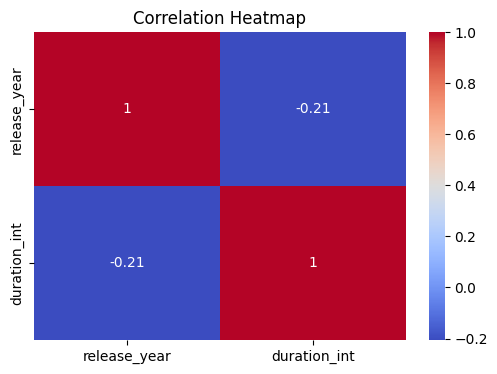

In [81]:
# Visualize correlation matrix using heatmap

plt.figure(figsize=(6,4))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### Insight:
The correlation between release year and movie duration is weak, indicating that movie length does not strongly depend on release year.